In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
import statsmodels.formula.api as smf
matplotlib.rc('font', serif='Helvetica Neue') 

In [45]:
KO = pd.read_csv('receptorKO.csv')

# using detection profile (all data)

In [46]:
esrs = ['JKAH24.1e', 'JKAH27.2d', 'JKAH27.2e', 
       'JKAH27.2h', 'JKAH28.1f', 'JKAH28.1g', 
       'JKAH29.1f', 'JKAH30.1d', 'JKAH30.1e']

prs =  ['JKAX4.3d', 'JKAX4.3e', 'JKAX6.2e','JKAX6.2f', 'JKAX6.2g', 
        'JKAX6.2h', 'JKAX7.3b',  'JKAX12.1d','JKAX12.1e', 'JKAX12.3d']

path = '~/Desktop/PhD_materials/negative_parental_switch/NPW_hormone/receptor_KO/quantification/'

knockout = prs
dfs = []
for id in knockout:
    df = pd.read_csv(path + id +'_detection.csv')
    
    df['mice_ID'] = [id] * df.shape[0]
    dfs.append(df)

dfs = pd.concat(dfs, ignore_index = True)

In [47]:
parental_behaviours = [ 'pup groom', 'retrieval to nest', 'nest time', 'nest building']
pr_behav = pd.read_csv('MPOA_progesterone_KO_behav.csv')
pr_behav['mice_ID'] = pr_behav['Observation id'].str[:-5]
parental_time = pr_behav[pr_behav.Behavior.isin(parental_behaviours)].groupby('mice_ID')['Duration (s)'].sum().reset_index(name = 'parental_time')

In [48]:
threshold = dfs['Cytoplasm: Opal 520 mean']

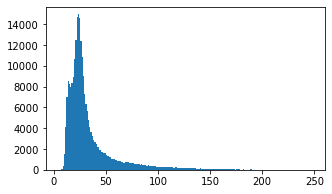

In [49]:
plt.subplot()
plt.rcParams["figure.figsize"] = (4,2)
counts, bins, bars = plt.hist(threshold, bins = 200)
hist_df = pd.DataFrame({'bins':bins[1:], 'counts':counts})

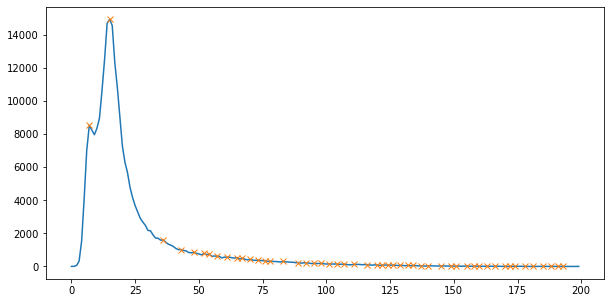

In [50]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(hist_df.counts, height=0)
plt.rcParams["figure.figsize"] = (10,5)
plt.plot(hist_df.counts)
plt.plot(hist_df.loc[peaks].counts, "x")
plt.show()

In [51]:
if knockout == prs:
    t = hist_df.loc[peaks].bins.tolist()[1]
else:
    t = hist_df.loc[peaks].bins.tolist()[0]

In [52]:
filtered_df = dfs[dfs['Cytoplasm: Opal 520 mean'] > t]
filtered_df = filtered_df.groupby(by = ['mice_ID'])['Cytoplasm: Opal 520 mean'].count().reset_index(name = 'count')

In [53]:
KO_dat = pd.merge(filtered_df, KO, on = 'mice_ID')

if knockout == prs:
    KO_dat = pd.merge(KO_dat, parental_time, on = 'mice_ID')
    
KO_dat = KO_dat[KO_dat.mice_ID.isin(knockout)]
KO_dat['dummy_x'] = [0] * KO_dat.shape[0]

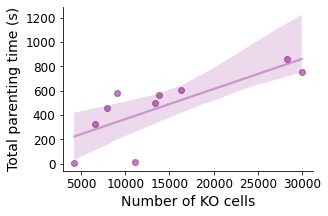

In [55]:
plt.rcParams["figure.figsize"] = (10,3)
if knockout == prs:
    # g = sns.stripplot(data=KO_dat, x="count", y = 'parental_time', hue = 'state',palette = ['Tab:red', 'green', 'gray'])
    # sns.despine()
    sns.lmplot(data=KO_dat, x="count", y = 'parental_time',
               height=3, aspect=1.5,
               scatter_kws = {'color' :'purple', 'alpha':0.5},
               line_kws = {'color' :'purple', 'alpha': 0.3})
    sns.despine()
    
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.xlabel('Number of KO cells', fontsize = 14)
    plt.ylabel('Total parenting time (s)', fontsize = 14)
    
    plt.savefig('progesterone_KO_quantification.jpg', dpi= 300)
    plt.show()
else:
    g = sns.lmplot(data=KO_dat, x="count", y = 'state_after_latency', 
                   height=3, aspect=1.5, 
                   scatter_kws = {'color' :'lightblue'},
                   line_kws = {'color' :'lightblue', 'alpha': 0.5})
    sns.despine()
    
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    plt.xlabel('Number of KO cells', fontsize = 14)
    plt.ylabel('Attack latency (s)', fontsize = 14)
    
    plt.savefig('estradiol_KO_quantification.jpg', dpi= 300)
    plt.show()

In [56]:
## statistic tests
if knockout == prs:
    model = smf.ols('count ~ parental_time ', data=KO_dat).fit()
    print(model.summary())
else:
   
    model = smf.ols('count ~ state_after_latency ', data=KO_dat).fit()
    print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     11.09
Date:                Tue, 28 Feb 2023   Prob (F-statistic):             0.0104
Time:                        20:14:46   Log-Likelihood:                -100.05
No. Observations:                  10   AIC:                             204.1
Df Residuals:                       8   BIC:                             204.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      3089.1610   3806.542      0.812

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/scipy/stats/stats.py:1604: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  "anyway, n=%i" % int(n))


In [13]:
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
parental_time,3.979982e+08,1.0,11.089187,0.010384
Residual,2.871252e+08,8.0,NaN,NaN


# per slice measurement

In [32]:
esrs = ['JKAH24.1e', 'JKAH27.2d', 'JKAH27.2e', 
       'JKAH27.2h', 'JKAH28.1f', 'JKAH28.1g', 
       'JKAH29.1f', 'JKAH30.1d', 'JKAH30.1e']
prs =  ['JKAX4.3e', 'JKAX6.2e','JKAX6.2f', 'JKAX6.2g', 'JKAX6.2h',
       'JKAX7.3b', 'JKAX7.3c', 'JKAX12.1d',
       'JKAX12.1e', 'JKAX12.3d']
ids = esrs + prs

path = '~/Desktop/PhD_materials/negative_parental_switch/NPW_hormone/receptor_KO/threshold_5/'
areas = [ "MPO", "MPN", "PS","PD", "ADP"]
dfs = []
for id in ids:
    df = pd.read_csv(path + id +'_detection.csv')
    
    df['mice_ID'] = [id] * df.shape[0]
    df = df.groupby(by = 'mice_ID').sum().reset_index()
    dfs.append(df)

dfs = pd.concat(dfs, ignore_index = True)
KO_dat = pd.merge(dfs, KO, on = 'mice_ID')
KO_dat['detection_area'] = KO_dat['Num Detections']/ KO_dat['Area µm^2']

## esr1 quantification

In [33]:
esr = KO_dat[KO_dat.mice_ID.isin(esrs)]

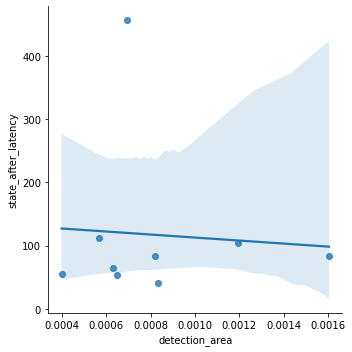

In [35]:
g = sns.lmplot(data=esr, x="detection_area", y = 'state_after_latency')
sns.despine()
plt.show()

In [36]:
model = smf.ols('detection_area ~ state_after_latency ', data=esr).fit()
model.summary()

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/scipy/stats/stats.py:1604: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         detection_area   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.138
Method:                 Least Squares   F-statistic:                   0.03212
Date:                Tue, 03 Jan 2023   Prob (F-statistic):              0.863
Time:                        14:06:42   Log-Likelihood:                 58.976
No. Observations:                   9   AIC:                            -114.0
Df Residuals:                       7   BIC:                            -113.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0008      0.000      4.668      0.002       0.000       0.001
state_after_latency -1.916e-07   1.07e-06     -0.179      0.863   -2.72e-06    2.34e-06
==============================================================================
Omnibus:                        5.002   Durbin-Watson:                   2.384
Prob(Omnibus):                  0.082   Jarque-Bera (JB):                1.842
Skew:                           1.096   Prob(JB):                        0.398
Kurtosis:                       3.325   Cond. No.                         234.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
state_after_latency,4.916664e-09,1.0,0.032117,0.862849
Residual,1.071612e-06,7.0,NaN,NaN


## PR quantification

In [251]:
pr = KO_dat[KO_dat.mice_ID.isin(prs)]
pr['dummy_x'] = [0] * pr.shape[0]

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


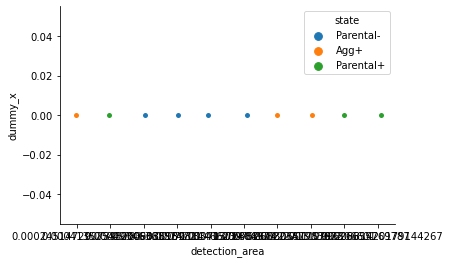

In [252]:
g = sns.stripplot(data=pr, x="detection_area", y = 'dummy_x', hue = 'state')
sns.despine()
plt.show()

In [253]:
model = smf.ols('detection_area ~ C(state) ', data=pr).fit()
model.summary()

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/scipy/stats/stats.py:1604: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         detection_area   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     1.576
Date:                Fri, 28 Oct 2022   Prob (F-statistic):              0.272
Time:                        19:00:06   Log-Likelihood:                 63.938
No. Observations:                  10   AIC:                            -121.9
Df Residuals:                       7   BIC:                            -121.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.0006      0.000      2.154      0.068   -5.87e-05       0.001
C(state)[T.Parental+]     0.0006      0.000      1.543      0.167      -0.000       0.002
C(state)[T.Parental-]  3.045e-05      0.000      0.082      0.937      -0.001       0.001
==============================================================================
Omnibus:                        2.667   Durbin-Watson:                   1.838
Prob(Omnibus):                  0.264   Jarque-Bera (JB):                0.330
Skew:                           0.203   Prob(JB):                        0.848
Kurtosis:                       3.792   Cond. No.                         3.93
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [243]:
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(state),7.368010e-07,2.0,1.575731,0.272266
Residual,1.636575e-06,7.0,NaN,NaN
